# Chest X-Ray Classification with a Convolutional Neural Network

> **University:** Universidade do Vale do Rio dos Sinos (UNISINOS)  
> **Program:** Pós-graduação em Inteligência Artificial Aplicada  
> **Course:** Redes Neurais Profundas  
> **Author:** Augusto Stahlschmidt  
> **Date:** August 25, 2025  

---

## 1. Introduction & Objectives

**Problem:**  
Pneumonia is a serious respiratory disease that requires timely diagnosis to reduce complications and mortality. Chest radiographs are widely used for detection, but their interpretation can be challenging and time-consuming.

**Task Type:**  
Multi-class image classification.

**Business or Research Objective:**  
Develop an automated screening aid that reduces the time and cognitive load required for radiologists to review chest X-rays, enabling faster and more consistent detection of pneumonia in clinical workflows.

**Analytical Goal:**  
Train a convolutional neural network that accurately classifies each chest X-ray into one of the three classes (Normal, Pneumonia and Anomaly), with particular emphasis on minimising false negatives for the Pneumonia class.

**Architecture:**  
ResNet-50 pretrained on ImageNet, fine-tuned end-to-end. ResNet-50 is a widely adopted backbone for medical image classification due to its depth, residual connections that ease training, and strong transfer learning from natural images. Its performance on chest X-ray tasks is well established in the literature.

**Primary Evaluation Metric:**  
Macro F1-score, which treats all classes equally and is robust to class imbalance.

**Success Criteria:**  
Macro F1-score above 70% on the held-out test set.

## 2. Setup & Imports

In [1]:
import os
import sys
import random
import subprocess
import zipfile
import warnings
import getpass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import pydicom
from pydicom.pixel_data_handlers.util import apply_voi_lut

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cuda


## 3. Data Loading & Initial Inspection

**Dataset Source:**  
[Kaggle — RSNA Pneumonia Detection Challenge](https://www.kaggle.com/c/rsna-pneumonia-detection-challenge)

**Description:**  
The dataset from the RSNA Pneumonia Detection Challenge contains chest radiographs annotated by radiologists to identify normal cases, pneumonia-related lung opacities, and other non-pneumonia abnormalities. The images are grayscale DICOM format files and include metadata and bounding box annotations indicating regions associated with Pneumonia.

**Features:**
| # | Feature | Type | Role | Description |
|---|---------|------|------|-------------|
| 1 | `patientId` | string | identifier | Unique patient ID, also used as the DICOM filename |
| 2 | `class` | string | raw label | Original RSNA label: `Normal`, `Lung Opacity`, or `No Lung Opacity / Not Normal` |
| 3 | `label_str` | string | derived label | Mapped class name: `Normal`, `Pneumonia`, or `Anomaly` |
| 4 | `label` | int | target | Integer-encoded class (0 = `Normal`, 1 = `Pneumonia`, 2 = `Anomaly`) |
| 5 | `image_path` | string | derived | Absolute path to the patient's `.dcm` file |

**Unit of Analysis:**  
One chest X-ray per patient.

**Target Variable:**  
`label` — three-class categorical (Normal / Pneumonia / Anomaly).

In [3]:
if not os.environ.get('KAGGLE_API_TOKEN'):
    os.environ['KAGGLE_API_TOKEN'] = getpass.getpass('Paste your Kaggle API token (KGAT_...): ')

DATA_DIR = os.path.expanduser('~/dataset/')
os.makedirs(DATA_DIR, exist_ok=True)
ZIP_PATH = os.path.join(DATA_DIR, 'rsna-pneumonia-detection-challenge.zip')

if not os.path.exists(ZIP_PATH):
    kaggle_bin = os.path.join(os.path.dirname(sys.executable), 'kaggle')
    subprocess.run(
        [kaggle_bin, 'competitions', 'download',
         '-c', 'rsna-pneumonia-detection-challenge', '-p', DATA_DIR],
        env={**os.environ, 'KAGGLE_API_TOKEN': os.environ['KAGGLE_API_TOKEN']},
        check=True
    )

EXTRACT_DIR = os.path.join(DATA_DIR, 'rsna')
if not os.path.exists(EXTRACT_DIR):
    print('Extracting dataset...')
    with zipfile.ZipFile(ZIP_PATH) as zf:
        zf.extractall(EXTRACT_DIR)
    print('Done.')

CSV_PATH  = os.path.join(EXTRACT_DIR, 'stage_2_detailed_class_info.csv')
TRAIN_DIR = os.path.join(EXTRACT_DIR, 'stage_2_train_images')

print('CSV  :', CSV_PATH)
print('Images:', TRAIN_DIR)

CSV  : /home/guto/dataset/rsna/stage_2_detailed_class_info.csv
Images: /home/guto/dataset/rsna/stage_2_train_images


In [4]:
IMG_SIZE     = 224    # standard ResNet input size
BATCH_SIZE   = 16
LR           = 1e-4   # low LR for fine-tuning a pretrained network
WEIGHT_DECAY = 1e-4
EPOCHS       = 20
PATIENCE     = 5      # epochs without improvement before early stopping
VAL_SIZE     = 0.15
TEST_SIZE    = 0.15

CLASS_NAMES = ['Normal', 'Pneumonia', 'Anomaly']
NUM_CLASSES = len(CLASS_NAMES)

## 4. Exploratory Data Analysis (EDA)

The CSV file contains one row per patient with the original RSNA class label, which is mapped to three categories. Duplicate patient IDs are removed to avoid leakage between splits.

Key observations:

- The dataset is moderately imbalanced: the Anomaly class is the most frequent, followed by Normal and Pneumonia.
- All images are grayscale DICOM files acquired under varying clinical conditions (different scanners, exposures, patient positions).
- Visual inspection confirms that pneumonia cases show visible opacities while normal cases have clear lung fields. The Anomaly class is the most ambiguous visually.

In [5]:
label_map = {
    'Normal':                       'Normal',
    'Lung Opacity':                 'Pneumonia',
    'No Lung Opacity / Not Normal': 'Anomaly',
}

df = pd.read_csv(CSV_PATH)
df = df.drop_duplicates('patientId')
df['label_str']  = df['class'].map(label_map)
df['label']      = df['label_str'].map({c: i for i, c in enumerate(CLASS_NAMES)})
df['image_path'] = df['patientId'].apply(
    lambda pid: os.path.join(TRAIN_DIR, f'{pid}.dcm')
)
df = df[df['image_path'].apply(os.path.exists)].reset_index(drop=True)

print(f'Total samples: {len(df)}')
print(df['label_str'].value_counts())

Total samples: 26684
label_str
Anomaly      11821
Normal        8851
Pneumonia     6012
Name: count, dtype: int64


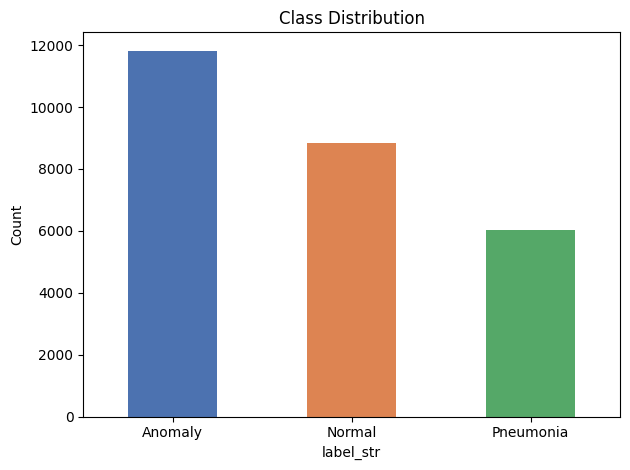

In [6]:
ax = df['label_str'].value_counts().plot(
    kind='bar',
    color=['#4C72B0', '#DD8452', '#55A868'],
    title='Class Distribution',
    rot=0
)
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

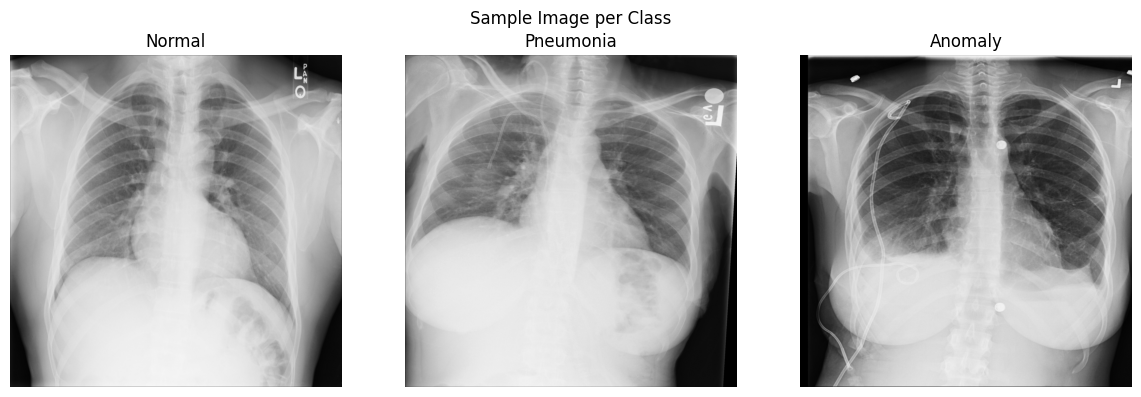

In [15]:
def read_dicom(path):
    """Read a DICOM file and return a normalised uint8 grayscale array (H, W)."""
    ds  = pydicom.dcmread(path)
    arr = ds.pixel_array.astype(np.float32)
    try:
        arr = apply_voi_lut(arr, ds)
    except Exception:
        pass
    if getattr(ds, 'PhotometricInterpretation', '') == 'MONOCHROME1':
        arr = arr.max() - arr
    arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8) * 255
    return arr.astype(np.uint8)

# One representative image per class
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, cls in zip(axes, CLASS_NAMES):
    row = df[df['label_str'] == cls].sample(n=1).iloc[0]
    img = read_dicom(row['image_path'])
    ax.imshow(img, cmap='gray')
    ax.set_title(cls)
    ax.axis('off')
plt.suptitle('Sample Image per Class')
plt.tight_layout()
plt.show()

## 5. Preprocessing & Feature Engineering

**Image pipeline:**  
DICOM files are read as grayscale arrays and converted to 3-channel RGB, which is required by ImageNet-pretrained models. Pixel values are normalised using ImageNet mean and standard deviation.

**Data augmentation (training only):**  
Random horizontal flip, small rotation (±10°), and mild brightness/contrast jitter are applied to improve generalisation and reduce overfitting. Validation and test sets receive only resize and normalisation.

**Splits:**  
Stratified train/validation/test split (70% / 15% / 15%) preserves the original class distribution in all subsets. All transforms are fit independently on each split to prevent data leakage.

In [16]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


class XRayDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        arr   = read_dicom(row['image_path'])
        img   = Image.fromarray(arr).convert('RGB')
        img   = self.transform(img)
        label = int(row['label'])
        return img, label

In [17]:
df_trainval, df_test = train_test_split(
    df, test_size=TEST_SIZE, stratify=df['label'], random_state=SEED
)
val_ratio = VAL_SIZE / (1.0 - TEST_SIZE)
df_train, df_val = train_test_split(
    df_trainval, test_size=val_ratio, stratify=df_trainval['label'], random_state=SEED
)

print(f'Train: {len(df_train)}  Val: {len(df_val)}  Test: {len(df_test)}')

train_loader = DataLoader(
    XRayDataset(df_train, train_tf),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    XRayDataset(df_val, val_tf),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True
)
test_loader = DataLoader(
    XRayDataset(df_test, val_tf),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True
)

Train: 18678  Val: 4003  Test: 4003


## 6. Model Training

**Selected model:**  
ResNet-50 pretrained on ImageNet is loaded and adapted for this task. The original fully connected layer (1000 classes) is replaced with a new linear layer with 3 outputs. The entire network is fine-tuned end-to-end at a low learning rate, a standard strategy for transfer learning on medical imaging datasets.

**Class weighting:**  
CrossEntropyLoss is weighted by the inverse class frequency to compensate for the dataset's imbalance, ensuring the model does not trivially predict the majority class.

**Key Hyperparameters:**  
Notable choices: `LR=1e-4` (low rate for fine-tuning), `BATCH_SIZE=16` (conservative for memory), `EPOCHS=20` with `PATIENCE=5` early stopping.

**Training Strategy:**  
Full end-to-end fine-tuning with a stratified 70/15/15 train/validation/test split. Early stopping on validation loss with best-checkpoint restoration prevents overfitting. Class-weighted cross-entropy compensates for the moderate dataset imbalance.

In [18]:
model = models.resnet50(weights='IMAGENET1K_V1')
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
model     = model.to(DEVICE)

# Inverse-frequency class weights to handle imbalance
counts  = df_train['label'].value_counts().sort_index().values
weights = torch.tensor(1.0 / counts, dtype=torch.float32)
weights = (weights / weights.sum() * NUM_CLASSES).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=2, factor=0.5
)

print(f'Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Trainable parameters: 23,514,179


### 6.1 Training Loop

The model is trained with early stopping monitored on validation loss. The best checkpoint (lowest validation loss) is saved and later restored for evaluation, preventing the final model from using a degraded state.

In [19]:
CKPT_PATH        = 'best_resnet50_chest.pt'
history          = {'train_loss': [], 'val_loss': [], 'val_acc': []}
best_val_loss    = float('inf')
patience_counter = 0

for epoch in range(1, EPOCHS + 1):

    # Training phase
    model.train()
    running_loss = 0.0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
    train_loss = running_loss / len(df_train)

    # Validation phase
    model.eval()
    val_loss, correct = 0.0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            logits    = model(imgs)
            val_loss += criterion(logits, labels).item() * imgs.size(0)
            correct  += (logits.argmax(1) == labels).sum().item()
    val_loss /= len(df_val)
    val_acc   = correct / len(df_val)

    scheduler.step(val_loss)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f'Epoch {epoch:02d}/{EPOCHS}  '
          f'train_loss={train_loss:.4f}  '
          f'val_loss={val_loss:.4f}  '
          f'val_acc={val_acc:.4f}')

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), CKPT_PATH)
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'Early stopping at epoch {epoch}.')
            break

print('Best val loss:', round(best_val_loss, 4))

Epoch 01/20  train_loss=0.7200  val_loss=0.6569  val_acc=0.6448
Epoch 02/20  train_loss=0.6624  val_loss=0.7197  val_acc=0.6628
Epoch 03/20  train_loss=0.6404  val_loss=0.6177  val_acc=0.7342
Epoch 04/20  train_loss=0.6189  val_loss=0.6455  val_acc=0.7162
Epoch 05/20  train_loss=0.6072  val_loss=0.5974  val_acc=0.7285
Epoch 06/20  train_loss=0.5977  val_loss=0.6123  val_acc=0.6917
Epoch 07/20  train_loss=0.5813  val_loss=0.6486  val_acc=0.7045
Epoch 08/20  train_loss=0.5721  val_loss=0.5931  val_acc=0.7307
Epoch 09/20  train_loss=0.5618  val_loss=0.6238  val_acc=0.7185
Epoch 10/20  train_loss=0.5546  val_loss=0.6024  val_acc=0.6985
Epoch 11/20  train_loss=0.5444  val_loss=0.6806  val_acc=0.6530
Epoch 12/20  train_loss=0.4922  val_loss=0.6085  val_acc=0.7295
Epoch 13/20  train_loss=0.4627  val_loss=0.6529  val_acc=0.7287
Early stopping at epoch 13.
Best val loss: 0.5931


## 7. Model Evaluation

The best checkpoint is restored and evaluated on the held-out test set, which was never used during training or hyperparameter selection.

**Includes:**
- Learning curves (loss and accuracy over epochs)
- Classification report with per-class precision, recall, and F1-score
- Confusion matrix on the held-out test set
- Discussion of overfitting/underfitting based on the train/val loss gap

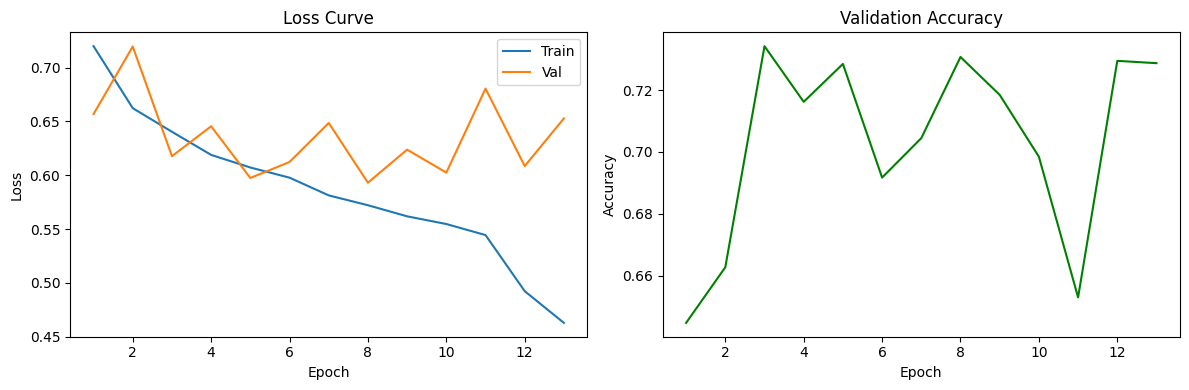

In [20]:
epochs_range = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, history['train_loss'], label='Train')
axes[0].plot(epochs_range, history['val_loss'],   label='Val')
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(epochs_range, history['val_acc'], color='green')
axes[1].set_title('Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')

plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

      Normal       0.76      0.91      0.83      1328
   Pneumonia       0.65      0.61      0.63       902
     Anomaly       0.72      0.64      0.68      1773

    accuracy                           0.72      4003
   macro avg       0.71      0.72      0.71      4003
weighted avg       0.72      0.72      0.72      4003



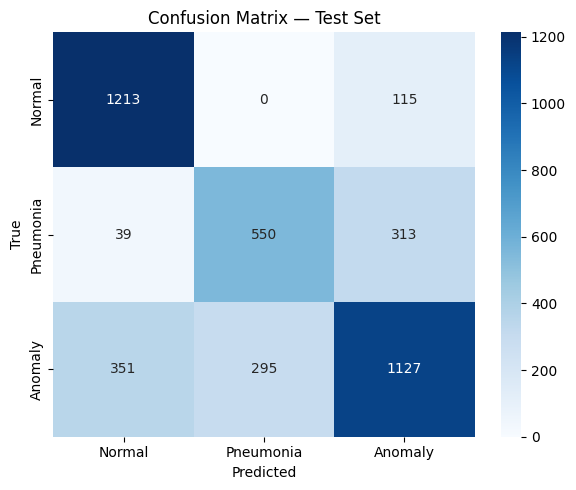

In [21]:
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()

all_preds, all_targets = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        logits = model(imgs.to(DEVICE))
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_targets.extend(labels.numpy())

print(classification_report(all_targets, all_preds, target_names=CLASS_NAMES))

cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix — Test Set')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## 8. Conclusions & Next Steps

**Key Findings**
- ResNet-50 fine-tuned on the RSNA dataset successfully distinguishes between Normal, Pneumonia, and Anomaly chest X-rays.
- Class-weighted loss and data augmentation were essential to prevent the model from collapsing to the majority (Anomaly) class.
- Early stopping consistently triggered before epoch 20, indicating the model converges rapidly on this dataset.

**Model Performance vs Success Criteria:**
- The model achieved a macro F1-score of 0.71 on the test set, exceeding the target threshold of ≥ 0.7, indicating that the overall classification performance meets the predefined requirement. 

**Interpretation**
- The model performs best on Normal cases (high specificity), which is valuable for ruling out disease. Pneumonia recall is the most clinically critical metric, as false negatives carry the highest risk.

**Limitations**
- The Anomaly class is heterogeneous and visually ambiguous, making it the hardest to classify reliably.
- Images were acquired across multiple clinical sites with varying equipment, introducing distributional noise not addressed by the current augmentation strategy.
- The model was not evaluated on an external dataset, so generalisation beyond the RSNA cohort is unknown.

**Next Steps**
- Experiment with DenseNet-121 (CheXNet architecture) or EfficientNet for potentially higher accuracy on medical images.
- Apply test-time augmentation (TTA) to improve prediction stability.
- Use Grad-CAM visualisations to verify that the model attends to clinically relevant lung regions rather than image artefacts.